# Feature detection

## Harris Corner detection

As always we start with the imports

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

To start, we will use the same checkerboard image as earlier.

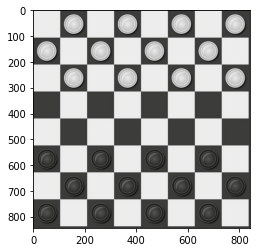

In [8]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 2/"
img = cv2.imread(path + 'checkers.png')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2a
Fill in the missing code in the next block. We would like to detect the corners of the image using the OpenCV function [`cv2.cornerHarris`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#gac1fc3598018010880e370e2f709b4345). Afterwards we want to draw the location of the detected corners on the image and display it.

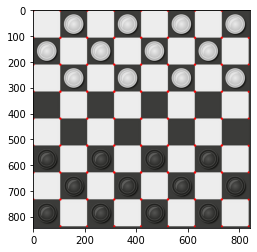

In [9]:
# Change image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

### Insert Harris Corner detector here ###
# The Harris Corner detector specifically requires the input image to be float32
gray = np.float32(gray)

# cv2.cornerHarris(src, blockSize, ksize, k)
# src - Input image.
# blockSize - The size of the neighborhood considered for corner detection (2 means a 2x2 neighborhood).
# ksize - Aperture parameter of the Sobel derivative used.
# k - Harris detector free parameter in the equation R = Det(M) - k*(Trace(M))^2.
# Common values for k are between 0.04 and 0.06.
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

### Draw the detected corners in the original image here ###
# Thresholding the result to find the corners.
# 'dst' contains the corner response value for every pixel.
# We create a boolean mask keeping only pixels where the response is greater than 5% (0.05) of the maximum response found in the image.
# This filters out weak corners or flat regions.
corners = np.argwhere(dst > 0.05 * dst.max())

for i in corners:
    # argwhere returns coordinates in (row, col) format, which corresponds to (y, x)
    y, x = i.ravel()
    # Draw a circle at the corner coordinates. -1 fills the circle.
    cv2.circle(img, (x, y), 3, 255, -1)

# Display image
plt.imshow(img)

## Shi-Tomasi
Next we will try the Shi-Tomasi feature detection method. In OpenCV, that method is implemented as [`cv2.goodFeaturesToTrack`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#ga1d6bb77486c8f92d79c8793ad995d541). 
Let's start with a different image this time.

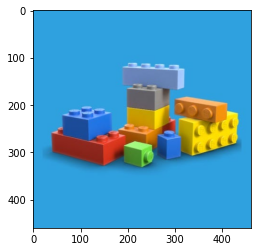

In [10]:
img = cv2.imread(path + 'Lego.jpg')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2b
Just like the previous exercise, detect the corners of the image by inserting the missing code, this time using the Shi-Tomasi (good features to track) method. Draw the detected corners on the image. Check the documentation of the function for help.

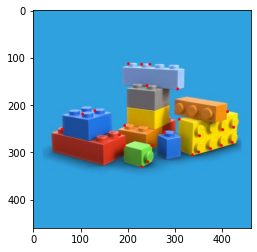

In [14]:
# Change image to grayscale
img_copy = img.copy()
gray = cv2.cvtColor(img_copy, cv2.COLOR_RGB2GRAY)

### Insert goodFeaturesToTrack detector here ###
# cv2.goodFeaturesToTrack(image, maxCorners, qualityLevel, minDistance)
corners = cv2.goodFeaturesToTrack(gray, 25, 0.01, 10)

# CORRECTED: Use np.int32 to avoid overflow on coordinates > 255
corners = np.int32(corners)

### Draw the detected corners in the original image here ###
for i in corners:
    # Flatten the array to get x, y
    x, y = i.ravel()
    # Note: For color images, it is safer to pass a tuple for color, e.g., (255, 0, 0) for Red
    cv2.circle(img_copy, (x, y), 3, (255, 0, 0), -1)

# Display image
plt.imshow(img_copy)

### Exercise 2c
Do a Harris corner detection on the same Lego image and compare the result with the Shi-Tomasi image.

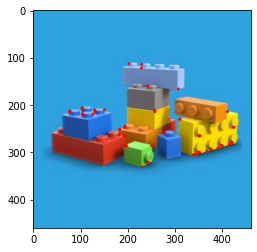

In [15]:
img_copy2 = img.copy()

# Cast to float32 again for Harris
gray = np.float32(gray)

# Run Harris with slightly different parameters this time
# increased ksize to 5 (larger Sobel kernel) and k to 0.1
dst = cv2.cornerHarris(gray, 2, 5, 0.1)

# Apply thresholding (keeping top 5% strongest corners)
corners = np.argwhere(dst > 0.05 * dst.max())
for i in corners:
    y, x = i.ravel()
    cv2.circle(img_copy2, (x, y), 3, 255, -1)

plt.imshow(img_copy2)